In [22]:
import utils
import methods
from utils import DataGenerator, Reservoir

import pyro as py
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
Time_steps = 2000
tau = 17
n = 10
beta = 0.2
gamma = 0.1
delta_t = 0.1

X, Y = DataGenerator(Time_steps, tau, n, beta, gamma, delta_t).generate_data()
X.shape, Y.shape

((2000, 1), (2000, 1))

In [3]:
X_train = X[:1000,:]
X_test = X[1000:,:]
X_train.shape, X_test.shape

((1000, 1), (1000, 1))

Input shape: (1000, 1)
Reservoir States shape: (1000, 500)


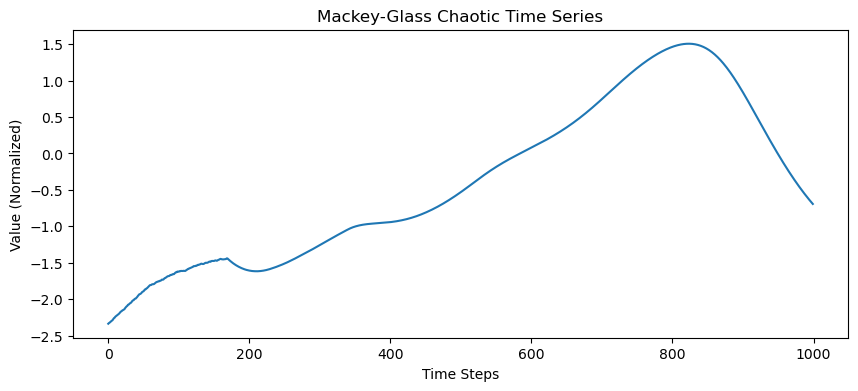

In [4]:
input_dim = X_train.shape[1]
reservoir_dim = 500
spectral_radius = 0.9
seed = 42

res = Reservoir(input_dim, reservoir_dim, spectral_radius, seed)

S_train = res.get_states(X_train)
S_test = res.get_states(X_test)

print(f"Input shape: {X_train.shape}")
print(f"Reservoir States shape: {S_train.shape}")

plt.figure(figsize=(10, 4))
plt.plot(X_train)
plt.title("Mackey-Glass Chaotic Time Series")
plt.xlabel("Time Steps")
plt.ylabel("Value (Normalized)")
plt.show()

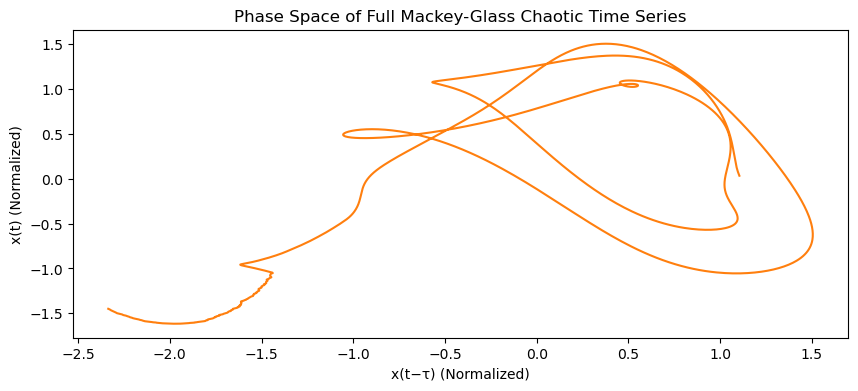

In [5]:
delay_steps = int(tau / delta_t)

plt.figure(figsize=(10, 4))
plt.plot(X[:-delay_steps], X[delay_steps:], color='C1')
plt.title("Phase Space of Full Mackey-Glass Chaotic Time Series")
plt.xlabel("x(t−τ) (Normalized)")
plt.ylabel("x(t) (Normalized)")
plt.show()

In [6]:
n_components = 16

S_train_PCA, S_test_PCA = utils.get_reduced_states(Reservoir(input_dim, reservoir_dim, spectral_radius, seed), X_train, X_test, n_components)

Original dim: (1000, 500)
Reduced dim:  (1000, 16)


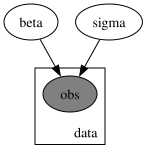

In [7]:
from methods import model
import pyro 
Y_train = Y[:1000]
pyro.render_model(model, model_args=(S_train, Y_train, [0,10.], [0,10.]))

$
\text{TotalCost}_{\text{HMC}} \approx (\text{Num Samples})\times(\text{Leapfrog Steps per Sample})\times(\text{Gradient Cost}),
$
with:
+ $\text{Gradient Cost} \sim \texttt{TimeSteps}\times\texttt{input\_dim}$
+ $\text{Leapfrog Steps} \sim \operatorname{O}(\texttt{input\_dim})$

Thus run $\text{HMC}$ sampler to sample $Y$. Two parameters will be shown. The $\texttt{step size}\,\,\Delta t$ is the integration step by used by the Leapfrog integrator. Pyro automatically identifies the value that allow to safely explore the whole distribution. The $\texttt{acc. prob}$ which is the frequency with which the sampler accepts the new proposed state at the end of a trajectory.

In [8]:
num_samples = 200

nut_kernel = pyro.infer.NUTS(model)
mcmc = pyro.infer.MCMC(nut_kernel, num_samples=num_samples, warmup_steps=200)
mcmc.run(S_train_PCA, Y_train)

Sample: 100%|██████████| 400/400 [01:09,  5.76it/s, step size=1.21e-01, acc. prob=0.941]


In [9]:
param_samples = mcmc.get_samples()

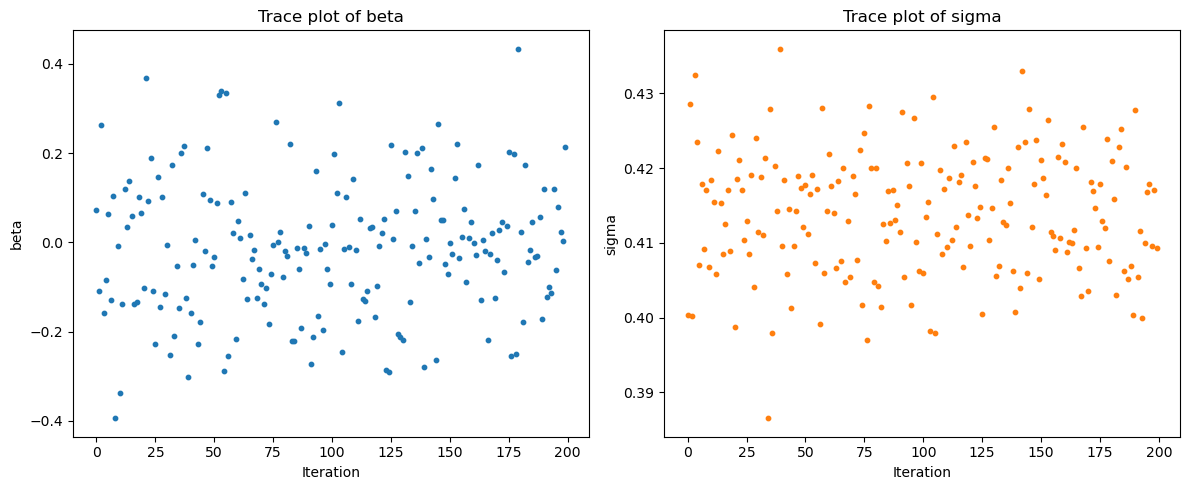

In [10]:
beta_samples = param_samples['beta'].squeeze().mean(1)
sigma_samples = param_samples['sigma'].squeeze()

iterations = np.arange(len(beta_samples))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(iterations, beta_samples, s=10, alpha=1)
plt.xlabel("Iteration")
plt.ylabel("beta")
plt.title("Trace plot of beta")

plt.subplot(1,2,2)
plt.scatter(iterations, sigma_samples, s=10, alpha=1, color="C1")
plt.xlabel("Iteration")
plt.ylabel("sigma")
plt.title("Trace plot of sigma")

plt.tight_layout()
plt.show()

In [11]:
# # Noice plotting
# import arviz as az
# az.plot_trace(mcmc)

The trajectory outlines a Posterior Predictive Distribution that allows to estimate the uncertainty in the MAP estimates in $\beta$ and $\sigma$, which is the ultimate goal of our Bayesian Reservoir Computer.

In [12]:
# # For quick fixes (to be commented out)

# def model(S, Y=None, beta_params=[0,1], sigma_params=[0,1]):

#     rows, cols = S.shape

#     S = torch.asarray(S, dtype = torch.float64)
#     if Y is not None: Y = torch.asarray(Y, dtype = torch.float64).squeeze()

#     beta = pyro.sample(
#         "beta",
#         pyro.distributions.Normal(
#             torch.tensor(beta_params[0], dtype=torch.float64),
#             torch.tensor(beta_params[1], dtype=torch.float64)
#         ).expand([cols]).to_event(1)
#     )
#     sigma = pyro.sample(
#         "sigma",
#         pyro.distributions.Uniform(
#             torch.tensor(sigma_params[0], dtype=torch.float64),
#             torch.tensor(sigma_params[1], dtype=torch.float64)
#         )
#     )
    
#     mu = torch.matmul(beta, S.mT)

#     with pyro.plate("data", rows):
#         pyro.sample(
#             "obs",
#             pyro.distributions.Normal(mu, sigma),
#             obs=Y,
#         )

In [13]:
Y_test = Y[1000:]
predictive = pyro.infer.Predictive(model, posterior_samples=param_samples, num_samples=None, parallel=True)
y_pred_samples = predictive(S_test_PCA, None)["obs"]

print("Shape of predictions:", y_pred_samples.shape)

Shape of predictions: torch.Size([200, 1000])


In [14]:
median_prediction = y_pred_samples.median(0)[0]
mean_prediction = y_pred_samples.mean(0)
std_prediction = y_pred_samples.std(0)

# 95% Confidence Interval
lower_bound = mean_prediction - 2 * std_prediction
upper_bound = mean_prediction + 2 * std_prediction

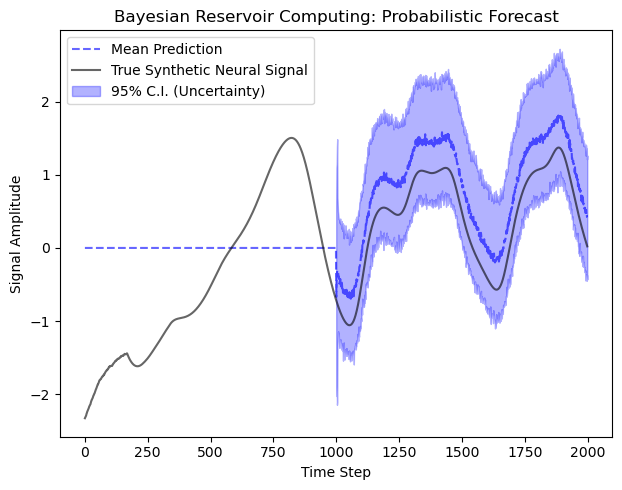

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(np.hstack((np.zeros(len(Y_train)), mean_prediction.detach().numpy())), "b--", alpha=0.6, label="Mean Prediction")
plt.plot(Y, "k-", alpha=0.6, label="True Synthetic Neural Signal")
plt.fill_between(
    range(len(Y_train), len(mean_prediction)+len(Y_train)),
    lower_bound,
    upper_bound,
    color="blue",
    alpha=0.3,
    label="95% C.I. (Uncertainty)"
)
plt.xlabel("Time Step")
plt.ylabel("Signal Amplitude")
plt.title("Bayesian Reservoir Computing: Probabilistic Forecast")
plt.tight_layout()
plt.legend()
plt.show()

Notice:
+ The predicted signal shows caothic dynamics (as it should), in the sense that is oscillates, aperiodically, without repeating the same pattern.
+ In a chaotic system, uncertainty is state-dependent, meaning the dynamics are predictable (narrow C.I.), for stable regions, and vice-versa for unstable regions.
+ The C.I. fully captures the true signal. The C.I. gets narrower when the signal changes direction less rapidly (iterations $\in(1100,1200)$).
We further test for a tighter noise interval. 

In [ ]:
num_samples_cnstr = 200

nut_kernel = pyro.infer.NUTS(model)
mcmc_cnstr = pyro.infer.MCMC(nut_kernel, num_samples=num_samples_cnstr, warmup_steps=200)

mcmc_cnstr.run(S_train_PCA, Y_train, beta_params=[0,1e0], sigma_params=[1e-2])
mcmc_cnstr.summary()

Sample: 100%|██████████| 400/400 [01:51,  3.60it/s, step size=1.53e-02, acc. prob=0.929]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]     -0.09      0.00     -0.09     -0.09     -0.09    171.21      1.00
   beta[1]     -0.10      0.00     -0.10     -0.10     -0.10    170.42      1.00
   beta[2]      0.10      0.00      0.10      0.09      0.10    205.68      1.00
   beta[3]      0.06      0.01      0.06      0.05      0.07    184.63      1.00
   beta[4]     -0.07      0.01     -0.07     -0.08     -0.06    170.18      1.00
   beta[5]      0.06      0.01      0.06      0.04      0.08    276.69      1.00
   beta[6]     -0.03      0.01     -0.03     -0.05     -0.01    217.18      1.00
   beta[7]     -0.10      0.02     -0.10     -0.14     -0.06    174.81      1.00
   beta[8]     -0.05      0.03     -0.05     -0.10     -0.02    129.69      1.02
   beta[9]     -0.01      0.04     -0.01     -0.07      0.05    166.74      1.01
  beta[10]      0.09      0.06      0.09      0.01      0.20    166.04      1.00
  beta[11]      0.06      0

In [17]:
param_samples_cnstr = mcmc_cnstr.get_samples()
predictive_cnstr = pyro.infer.Predictive(model, posterior_samples=param_samples_cnstr, num_samples=None, parallel=True)
y_pred_samples_cnstr = predictive_cnstr(S_test_PCA, None)["obs"]

median_prediction_cnstr = y_pred_samples_cnstr.median(0)[0]
mean_prediction_cnstr = y_pred_samples_cnstr.mean(0)
std_prediction_cnstr = y_pred_samples_cnstr.std(0)

lower_bound_cnstr = mean_prediction_cnstr - 2 * std_prediction_cnstr
upper_bound_cnstr = mean_prediction_cnstr + 2 * std_prediction_cnstr

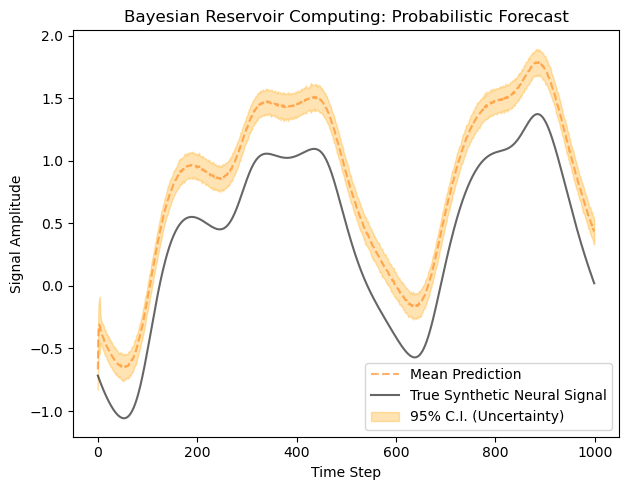

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(mean_prediction_cnstr, "C1--", alpha=0.6, label="Mean Prediction")
plt.plot(Y_test, "k-", alpha=0.6, label="True Synthetic Neural Signal")
plt.fill_between(
    range(len(mean_prediction_cnstr)),
    lower_bound_cnstr,
    upper_bound_cnstr,
    color="orange",
    alpha=0.3,
    label="95% C.I. (Uncertainty)"
)
plt.xlabel("Time Step")
plt.ylabel("Signal Amplitude")
plt.title("Bayesian Reservoir Computing: Probabilistic Forecast")
plt.tight_layout()
plt.legend()
plt.show()

For a very tightly bounded $\sigma$-prior $\sim\text{Unif}(0,<1)$, inference overfits on the training data and the uncertainty band does not include the true signal.

Noticing the fact that sometimes the true signal does not fall inside the uncertainty bands, we aim to formally evaluate the model using metrics that penalize both for being wrong (inexact signal amplitude / too narrow condifence interval) and "unecessarily unsure" (too wide confidence interval). We use a twofold approach:
+ Calibration Error (cal): ( from the paper "how much the empirical CDF veers from the theoretical one"). Namely:
    $$
    \text{cal}=\sum_{i=1}^K w_i (\tau_i - \tilde{\tau}_i)^2
    $$
+ Empirical Coverage (ecov):  Measures the width and the coverage of the $95\%\, \text{C.I.}$. A smaller width reflects a less uncertain forecast, while the coverage should be close to $0.95$. Namely
    $$
    \text{ecov} = \frac{1}T\sum_{i=t}^T\mathbb{1}_{[\text{CI}_{\text{low}}\,\le\, y_t \,\le\, \text{CI}_{\text{high}}]}
    $$
+ mCRPS (mean Continuous Ranked Probability Score): measures the average distance between the predicted CDF and the Heaviside function $\theta$. CRPS can be interpreted as a combined
measure of both the accuracy (MSE) and calibration (cal).
    $$
    \mathrm{CRPS}(F, x)
    =
    \int \big( F(y) - \theta(y - x) \big)^2 \, dy.\\
    \mathrm{mCRPS}(F) = \mathbb{E}_y \big[ \mathrm{CRPS}(F, y) \big].
    $$

In [19]:
# constrained results (sigma ~ Unif[0,<1.])
ecov, cal, mcrps = methods.evaluate_metrics(y_pred_samples_cnstr, Y_test)

print(f"Empirical Coverage (constrained): {ecov:.2%} (Target: 95%)")
print(f"Calibration Error (constrained): {cal:.2%} (Target: 0%)")
print(f"mCRPS (constrained): {mcrps:.4f} (Lower is better)")

Empirical Coverage (constrained): 6.49% (Target: 95%)
Calibration Error (constrained): 48.05% (Target: 0%)
mCRPS (constrained): 0.3382 (Lower is better)


In [20]:
# results for unconstrained sigma ~ Unif[0,10.])
ecov, cal, mcrps = methods.evaluate_metrics(y_pred_samples, Y_test)

print(f"Empirical Coverage (unconstrained): {ecov:.2%} (Target: 95%)")
print(f"Calibration Error (unconstrained): {cal:.2%} (Target: 0%)")
print(f"mCRPS (unconstrained): {mcrps:.4f} (Lower is better)")

Empirical Coverage (unconstrained): 54.89% (Target: 95%)
Calibration Error (unconstrained): 13.39% (Target: 0%)
mCRPS (unconstrained): 0.1983 (Lower is better)


In summary, 

The Reservoir acts as a fixed, non-linear dynamical filter that projects the low-dimensional input to a high-dimensional **state space**, determined by the projection $s(t)=f(W_{\text{in}} x(t) + W s(t-1)).$ This allows the system to develop a "short-term memory" required to predict the chaotic Mackey-Glass system (where the future depends on $t-\tau$).

The Bayesian Regression layer then takes these states and maps them to the output. Unlike standard regression, it treats the weights $\beta$ and noise $\sigma$ as **stochastic** variables, defined by the posterior probability distribution $P(\beta, \sigma|\mathcal{D})$. This allows us to quantify:
+ The **epistemic** uncertainty (uncertainty about the dynamics). Quantified the variance of the posterior predictive mean $\operatorname{Var}(s(t)^T\beta)$.
+ The **aleatoric** uncertainty (measurement noise). Quantified by the observation noise variance $\sigma^2$, representing the stochasticity of the system measurements and providing a "cloud of probability" (the C.I. band) that tracks the chaotic attractor.

A constrained model (prior for the observation noise variance $\sigma\sim\mathcal{U}[0, 0.05]$) leads to a sharper C.I. band, able to reproduce the dynamics of the true signal. However, scoring a low empirical coverage. The unconstrained model performs better over all metrics. 

Now, we want to quantify the trade-off between calibration (empirical coverage approaching 0.95) and sharpness (minimization of CRPS), across the two probabilistic regimes.

In [23]:
constraints = [
    [0, 1e2], [0, 1e1], [0,1e0], [0, 1e-1], [0, 1e-2], [0, 1e-3]
    ]
num_samples_ = 200
warmup_steps_ = 200
n_metrics = 3
metrics = torch.zeros(
    (n_metrics, len(constraints))
    )

for (i, sigma_) in enumerate(constraints):
    print("\n\n", f"{i+1}.", f"sigma_params = {sigma_}")

    nut_kernel_ = pyro.infer.NUTS(model)
    mcmc_ = pyro.infer.MCMC(
        nut_kernel_, num_samples=num_samples_, warmup_steps=warmup_steps_
        )
    mcmc_.run(
        S_train_PCA, Y_train, 
        beta_params=[0,1e0], sigma_params=sigma_
        )
    param_samples_ = mcmc_.get_samples()
    predictive_ = pyro.infer.Predictive(
        model, posterior_samples=param_samples_, 
        num_samples=None, parallel=True
        )
    y_pred_samples_ = predictive_(S_test_PCA, None)["obs"]

    ecov_, cal_, mcrps_ = methods.evaluate_metrics(y_pred_samples_, Y_test)
    metrics[:,i] = torch.tensor([ecov_, cal_, mcrps_])



 1. sigma_params = [0, 100.0]


Sample: 100%|██████████| 400/400 [01:02,  6.43it/s, step size=1.35e-01, acc. prob=0.923]




 2. sigma_params = [0, 10.0]


Sample: 100%|██████████| 400/400 [01:03,  6.28it/s, step size=1.29e-01, acc. prob=0.928]




 3. sigma_params = [0, 1.0]


...

Sample: 100%|██████████| 400/400 [00:44,  8.95it/s, step size=2.63e-02, acc. prob=0.951]




 5. sigma_params = [0, 0.01]


Sample: 100%|██████████| 400/400 [01:24,  4.71it/s, step size=2.65e-03, acc. prob=0.940] 




 6. sigma_params = [0, 0.001]


Sample: 100%|██████████| 400/400 [00:03, 116.03it/s, step size=3.19e-04, acc. prob=0.928]


In [24]:
results = methods.quantify_tradeoff(constraints, metrics)

In [25]:
results

,Regime,Empirical Coverage,Calibration Error,mCRPS,Sharpness Degradation
0,"[0, 100.0]",0.546191,0.135151,0.199244,-0.000512
1,"[0, 10.0]",0.546136,0.134794,0.198732,0.000000
2,"[0, 1.0]",0.546031,0.135434,0.200049,-0.001317
3,"[0, 0.1]",0.139215,0.418345,0.337953,-0.139221
4,"[0, 0.01]",0.034117,0.509567,0.338108,-0.139376
5,"[0, 0.001]",0.034980,0.509856,0.337916,-0.139184
